# 01 – Data Fetching Demo

This notebook demonstrates how to use our `data/fetch_data.py` utility to load market prices
and visualize them. We will:

1. Fetch data for a small set of tickers
2. Inspect the raw inputs
3. Plot the price series


In [21]:
# Imports
import os, sys, numpy as np, matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams["font.family"] = "Times New Roman" # Set font to Times New Roman
# Add the repo root (one level up from notebooks) to Python path
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(repo_root)


from data.fetch_data import load_prices


### Step 1: Choose tickers and time window


In [22]:
### Step 1: Choose tickers and time window
tickers = ["META", "AAPL", "NFLX", "GOOGL", "AMZN"]
start_date = "2024-01-01"
end_date = "2024-12-31"


### Step 2: Fetch prices
We use the `load_prices` function from our package.  
This returns a **wide DataFrame**: rows = dates, columns = tickers.


In [23]:
prices = load_prices(tickers, start=start_date, end=end_date)
print("Shape:", prices.shape)
print("Columns:", prices.columns.tolist())
print(prices.head())


Shape: (251, 5)
Columns: ['AAPL', 'AMZN', 'GOOGL', 'META', 'NFLX']
Ticker            AAPL        AMZN       GOOGL        META        NFLX
Date                                                                  
2024-01-02  184.081497  149.929993  137.223557  344.168304  468.500000
2024-01-03  182.703171  148.470001  137.968430  342.359436  470.260010
2024-01-04  180.382828  144.570007  135.455765  344.993195  474.670013
2024-01-05  179.658936  145.240005  134.800262  349.793671  474.059998
2024-01-08  184.002182  149.100006  137.888977  356.462524  485.029999


### Step 3: Plot price series


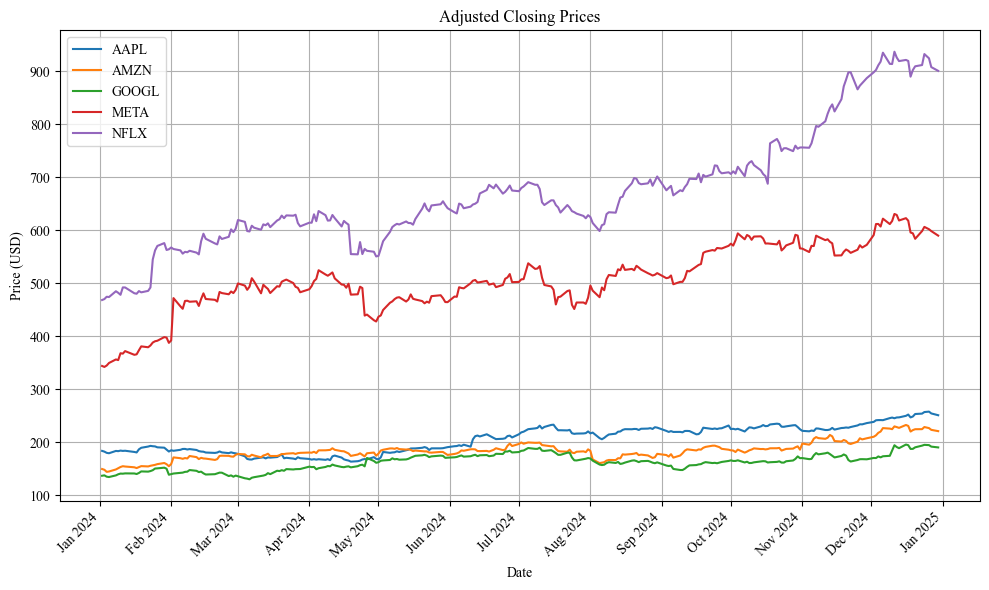

In [24]:

plt.figure(figsize=(10, 6))
ax = plt.gca()

prices.plot(ax=ax)

# Format x-axis by month
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # tick every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # e.g. "Jan 2022"

plt.title("Adjusted Closing Prices")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.legend(loc="upper left")

plt.xticks(rotation=45)  # rotate labels for readability
plt.tight_layout()
plt.show()


### Step 4: Plot normalized (rebased) prices
Often we normalize all tickers to start at 1.0 to compare growth.


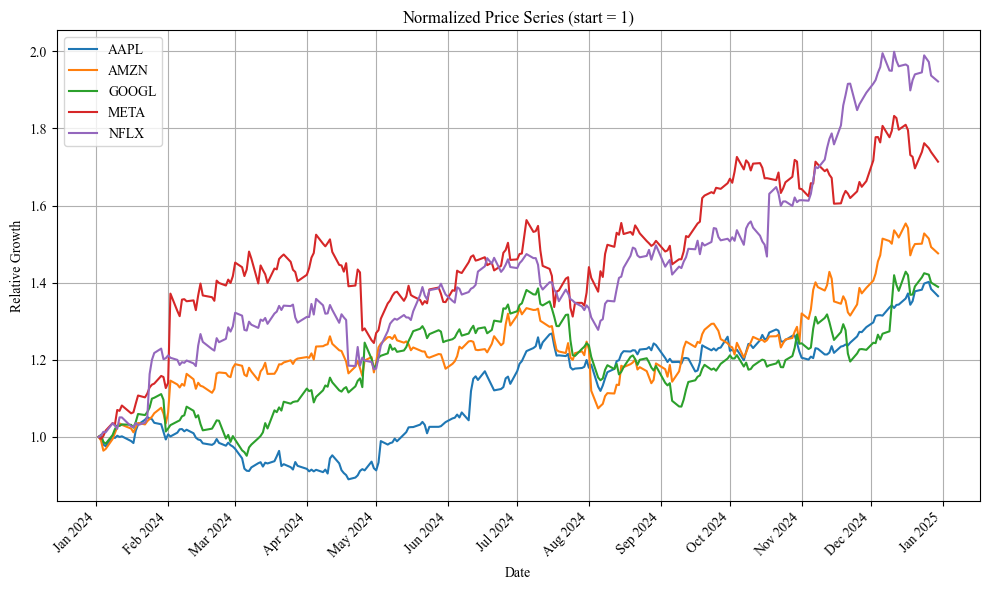

In [25]:
normalized = prices / prices.iloc[0]
plt.figure(figsize=(10, 6))
ax = plt.gca()

normalized.plot(ax=ax)

# Format x-axis to show months
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))   # tick every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))   # e.g. "Jan 2022"

plt.title("Normalized Price Series (start = 1)")
plt.ylabel("Relative Growth")
plt.xlabel("Date")
plt.grid(True)
plt.legend(loc="upper left")

plt.xticks(rotation=45)  # rotate labels
plt.tight_layout()
plt.show()

## How We Calculate Weights and Portfolio Value

### 1. Calculating Weights
- For each stock (ticker), we obtain the **free float**:  
  the number of shares available for trading (excluding insider holdings, restricted shares, etc.).
- We then compute the **total free float** across all stocks in the portfolio:
  $
  \text{Total Free Float} = \sum_i \text{Free Float}(i)
  $
- The **weight** of each stock is its share of the total free float:
  $
  w_i = \frac{\text{Free Float}(i)}{\text{Total Free Float}}
  $
- These weights ensure that stocks with larger free floats (i.e., more liquid, widely traded)  
  have a proportionally larger influence on the portfolio.

---

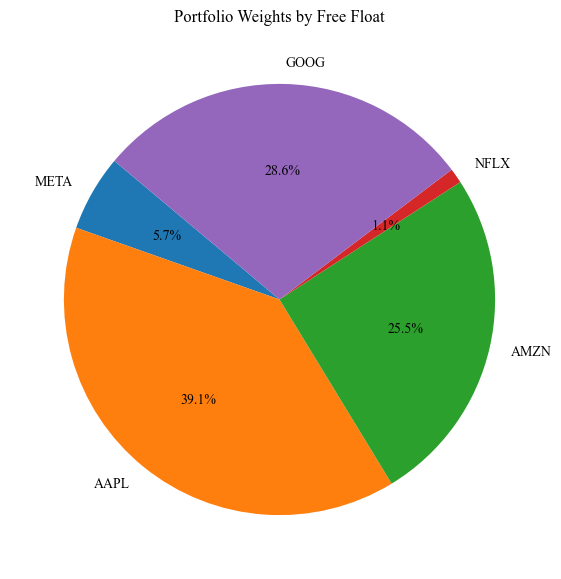

In [26]:

from portfolio.free_float import build_portfolio_from_free_float
#FAANG
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

# Build weights and portfolio
df_w, df_p = build_portfolio_from_free_float(
    tickers,
    start="2024-01-01",
    end="2025-01-01",
    initial_investment=1000.0
)


weights = df_w.set_index("Ticker")["Free Float Weight"].dropna()

plt.figure(figsize=(7,7))
plt.pie(weights, labels=weights.index, autopct="%1.1f%%", startangle=140)
plt.title("Portfolio Weights by Free Float")
plt.show()

### 2. Calculating Portfolio Value
- For each day $t$, we calculate the **percentage change** (daily return) of each stock:
  $
  r_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}
  $
  where $P_{i,t}$ is the closing price of stock $i$ at time $t$.

- The **portfolio return** on day $t$ is the weighted sum of individual returns:
  $
  R_t = \sum_i w_i \cdot r_{i,t}
  $

- Starting from an initial investment $V_0$ (e.g., \$1000),  
  the portfolio value updates each day via compounding:
  $
  V_t = V_{t-1} \times (1 + R_t)
  $

---

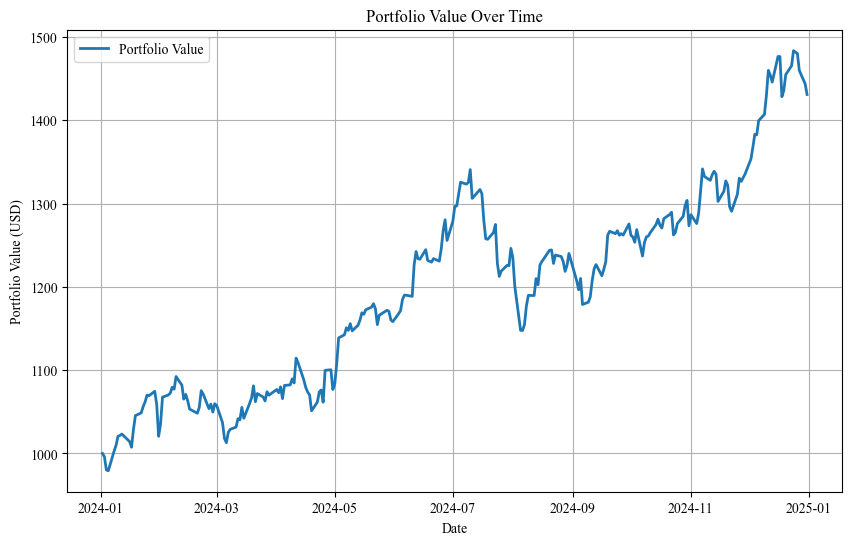

In [27]:
# Plot portfolio value vs time
plt.figure(figsize=(10, 6))
plt.plot(df_p.index, df_p["Portfolio Value"], label="Portfolio Value", linewidth=2)
plt.title("Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (USD)")
plt.grid(True)
plt.legend()
plt.show()


## Portfolio vs. Single Stock Comparison

In the chart, we overlay the **portfolio value** against **Apple’s (AAPL) price performance**, both normalized to start at the same initial value (e.g., $1000).  



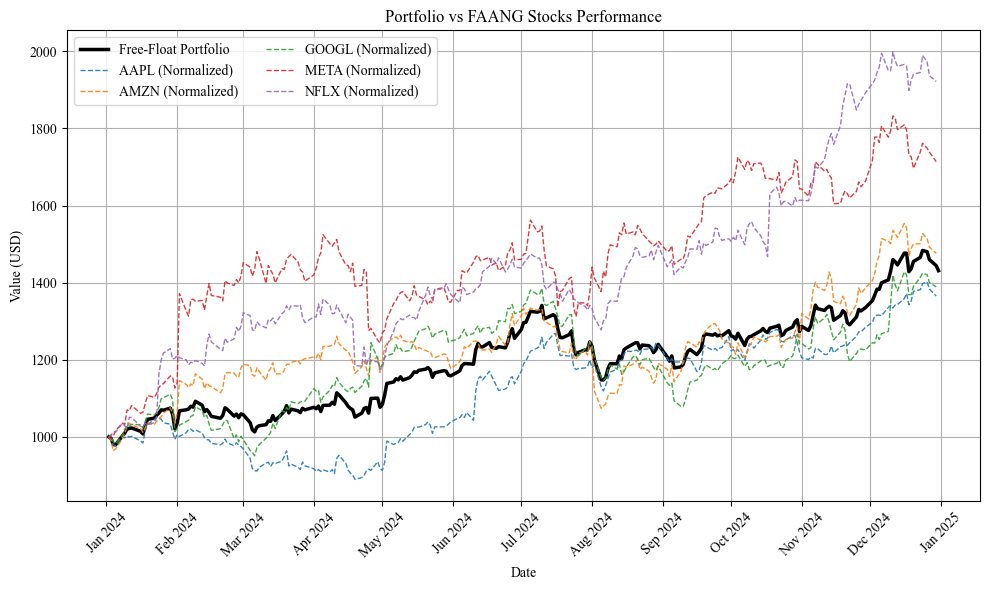

In [28]:
# Normalize to start at 1000
normalized = prices / prices.iloc[0] * 1000

plt.figure(figsize=(10, 6))




# Portfolio (thicker line)
plt.plot(df_p.index, df_p["Portfolio Value"], label="Free-Float Portfolio", linewidth=2.5,color='black')

# FAANG stocks (thinner dashed lines)
for col in normalized.columns:
    plt.plot(
        normalized.index,
        normalized[col],
        linestyle="--",
        linewidth=1.0,   # thinner
        alpha=0.9,       # slightly transparent (optional)
        label=f"{col} (Normalized)"
    )



# Formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title("Portfolio vs FAANG Stocks Performance")
plt.ylabel("Value (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.legend(loc="upper left", ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Equal weigts

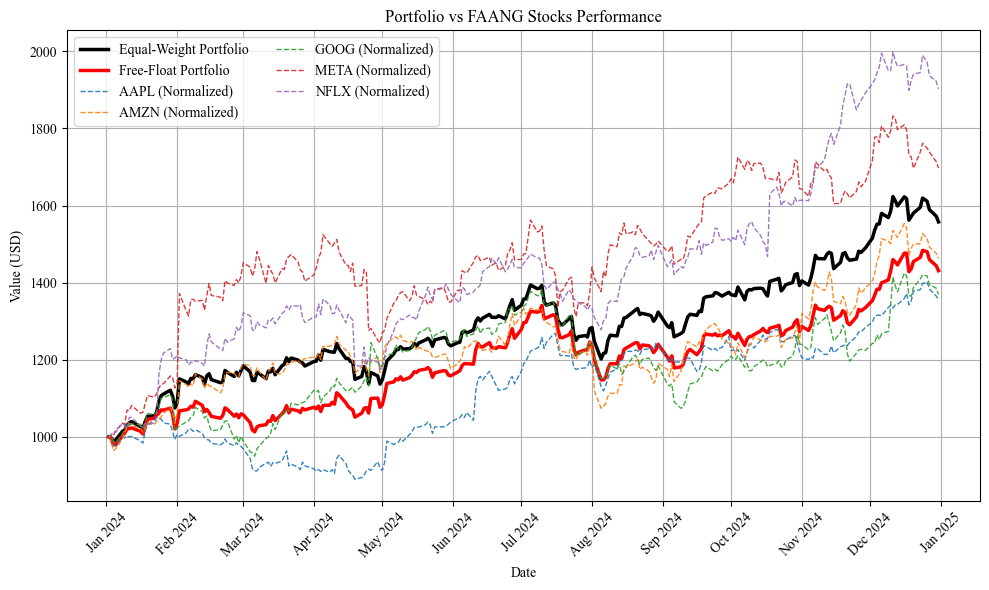

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from data.fetch_data import load_prices

# ----------------------------
# Parameters
# ----------------------------
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
start="2024-01-01"
end="2025-01-01"

# ----------------------------
# Download adjusted close prices
# ----------------------------
prices = load_prices(tickers, start=start, end=end, auto_adjust=True)

# ----------------------------
# Build equal-weight portfolio value
# ----------------------------
weights = {t: 1 / len(tickers) for t in tickers}

# Normalize to start at 1000
normalized = prices / prices.iloc[0] * 1000

# Equal-weight portfolio normalized to 1000
w = 1 / normalized.shape[1]
portfolio_norm_1000 = (prices / prices.iloc[0]).mul(w).sum(axis=1) * 1000

plt.figure(figsize=(10, 6))

# Portfolio (thicker line)
plt.plot(
    portfolio_norm_1000.index,
    portfolio_norm_1000.values,
    label="Equal-Weight Portfolio",
    linewidth=2.5,
    color="black"
)
plt.plot(df_p.index, df_p["Portfolio Value"], label="Free-Float Portfolio", linewidth=2.5,color='red')
# FAANG stocks (thinner dashed lines)
for col in normalized.columns:
    plt.plot(
        normalized.index,
        normalized[col],
        linestyle="--",
        linewidth=1.0,
        alpha=0.9,
        label=f"{col} (Normalized)"
    )

# Formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title("Portfolio vs FAANG Stocks Performance")
plt.ylabel("Value (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.legend(loc="upper left", ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()